# Train model

In [32]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [33]:
filename = os.path.join(context['portfolio_dir'], hayai_util.FILE_FEATURES)
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.replace([float('inf'), float('-inf')], float('nan'))
df = df.dropna()
df.shape

(379524, 42)

In [34]:
df.columns

Index(['AUDUSD', 'BZ', 'CNYUSD', 'EURUSD', 'GBPUSD', 'GC', 'NZDUSD', 'USDCAD',
       'USDCHF', 'USDJPY', '^DJI', '^GSPC', '^IXIC', '^RUT', '^VIX1D',
       'close_range', 'country_Canada', 'country_China',
       'country_United States', 'date', 'day_of_week', 'hl_range',
       'log_return', 'mom_10', 'mom_20', 'mom_5', 'mom_rank', 'mom_vol_adj',
       'sector_Health Care', 'sector_Real Estate', 'sector_Technology',
       'symbol', 'target', 'time_since_high', 'trend_50', 'vol_10', 'vol_20',
       'vol_ratio', 'vol_regime', 'volume_shock', 'volume_zscore',
       'zscore_20'],
      dtype='str')

## EDA

In [35]:
df.describe()

,AUDUSD,BZ,CNYUSD,EURUSD,GBPUSD,GC,NZDUSD,USDCAD,USDCHF,USDJPY,...,target,time_since_high,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume_shock,volume_zscore,zscore_20
count,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,...,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000,379524.000000
mean,0.656723,75.831383,0.139632,1.106449,1.292543,2854.249164,0.596557,1.374785,0.857270,149.480262,...,0.047317,438.088321,0.015095,0.042164,0.049556,0.872076,0.936497,1.010571,0.030671,0.111045
std,0.019162,8.865144,0.002143,0.043376,0.041694,900.112774,0.018119,0.028899,0.043872,5.742759,...,1.262024,355.680650,0.113606,0.031964,0.033910,0.274416,0.365616,0.512572,1.034476,1.291872
min,0.595529,58.919998,0.136054,1.024443,1.207846,1816.599976,0.551849,1.311250,0.763200,133.464996,...,-3.000000,0.000000,-0.319204,0.005037,0.006237,0.258159,0.306501,0.278653,-1.560987,-2.618038
25%,0.644990,68.589996,0.137992,1.076670,1.262148,2034.000000,0.584300,1.356420,0.808130,145.613007,...,-0.657431,75.000000,-0.046443,0.020838,0.026531,0.669967,0.671909,0.693580,-0.643552,-0.947976
50%,0.655680,75.580002,0.139289,1.092777,1.281263,2626.500000,0.597011,1.370210,0.872490,149.304993,...,0.057145,429.000000,0.010356,0.032926,0.040144,0.889522,0.879495,0.892262,-0.240732,0.173164
75%,0.667300,82.400002,0.140677,1.152804,1.332747,3347.699951,0.610381,1.388460,0.895200,154.335999,...,0.768263,723.000000,0.069692,0.052899,0.062149,1.089152,1.136799,1.171437,0.425152,1.166961
max,0.712921,112.190002,0.146180,1.201764,1.382533,5318.399902,0.639190,1.471700,0.920970,161.606995,...,3.000000,1250.000000,0.399295,0.186649,0.197724,1.371212,2.027137,3.412110,3.672525,2.697284


In [36]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 379524 entries, 472 to 617906
Data columns (total 40 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AUDUSD                 379524 non-null  float64
 1   BZ                     379524 non-null  float64
 2   CNYUSD                 379524 non-null  float64
 3   EURUSD                 379524 non-null  float64
 4   GBPUSD                 379524 non-null  float64
 5   GC                     379524 non-null  float64
 6   NZDUSD                 379524 non-null  float64
 7   USDCAD                 379524 non-null  float64
 8   USDCHF                 379524 non-null  float64
 9   USDJPY                 379524 non-null  float64
 10  ^DJI                   379524 non-null  float64
 11  ^GSPC                  379524 non-null  float64
 12  ^IXIC                  379524 non-null  float64
 13  ^RUT                   379524 non-null  float64
 14  ^VIX1D                 379524 non-null  float64
 1

In [37]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

## Target analysis

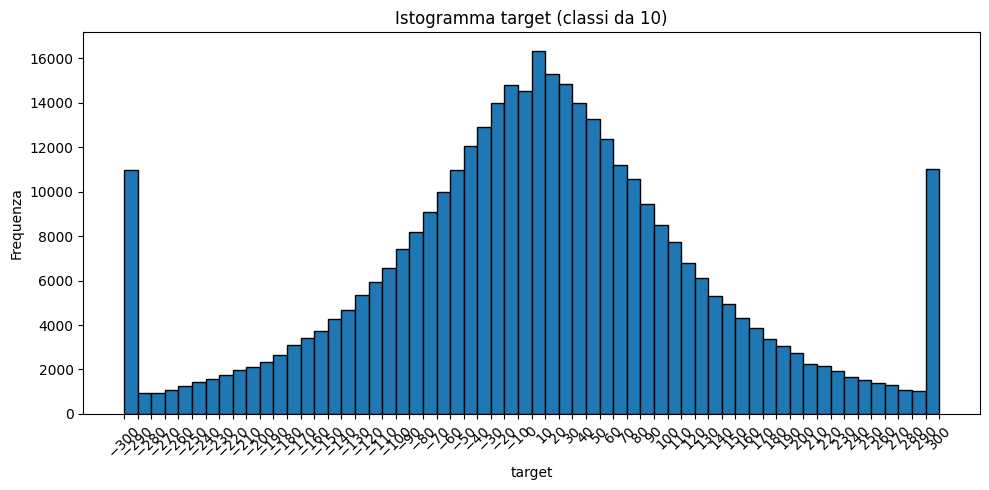

In [38]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

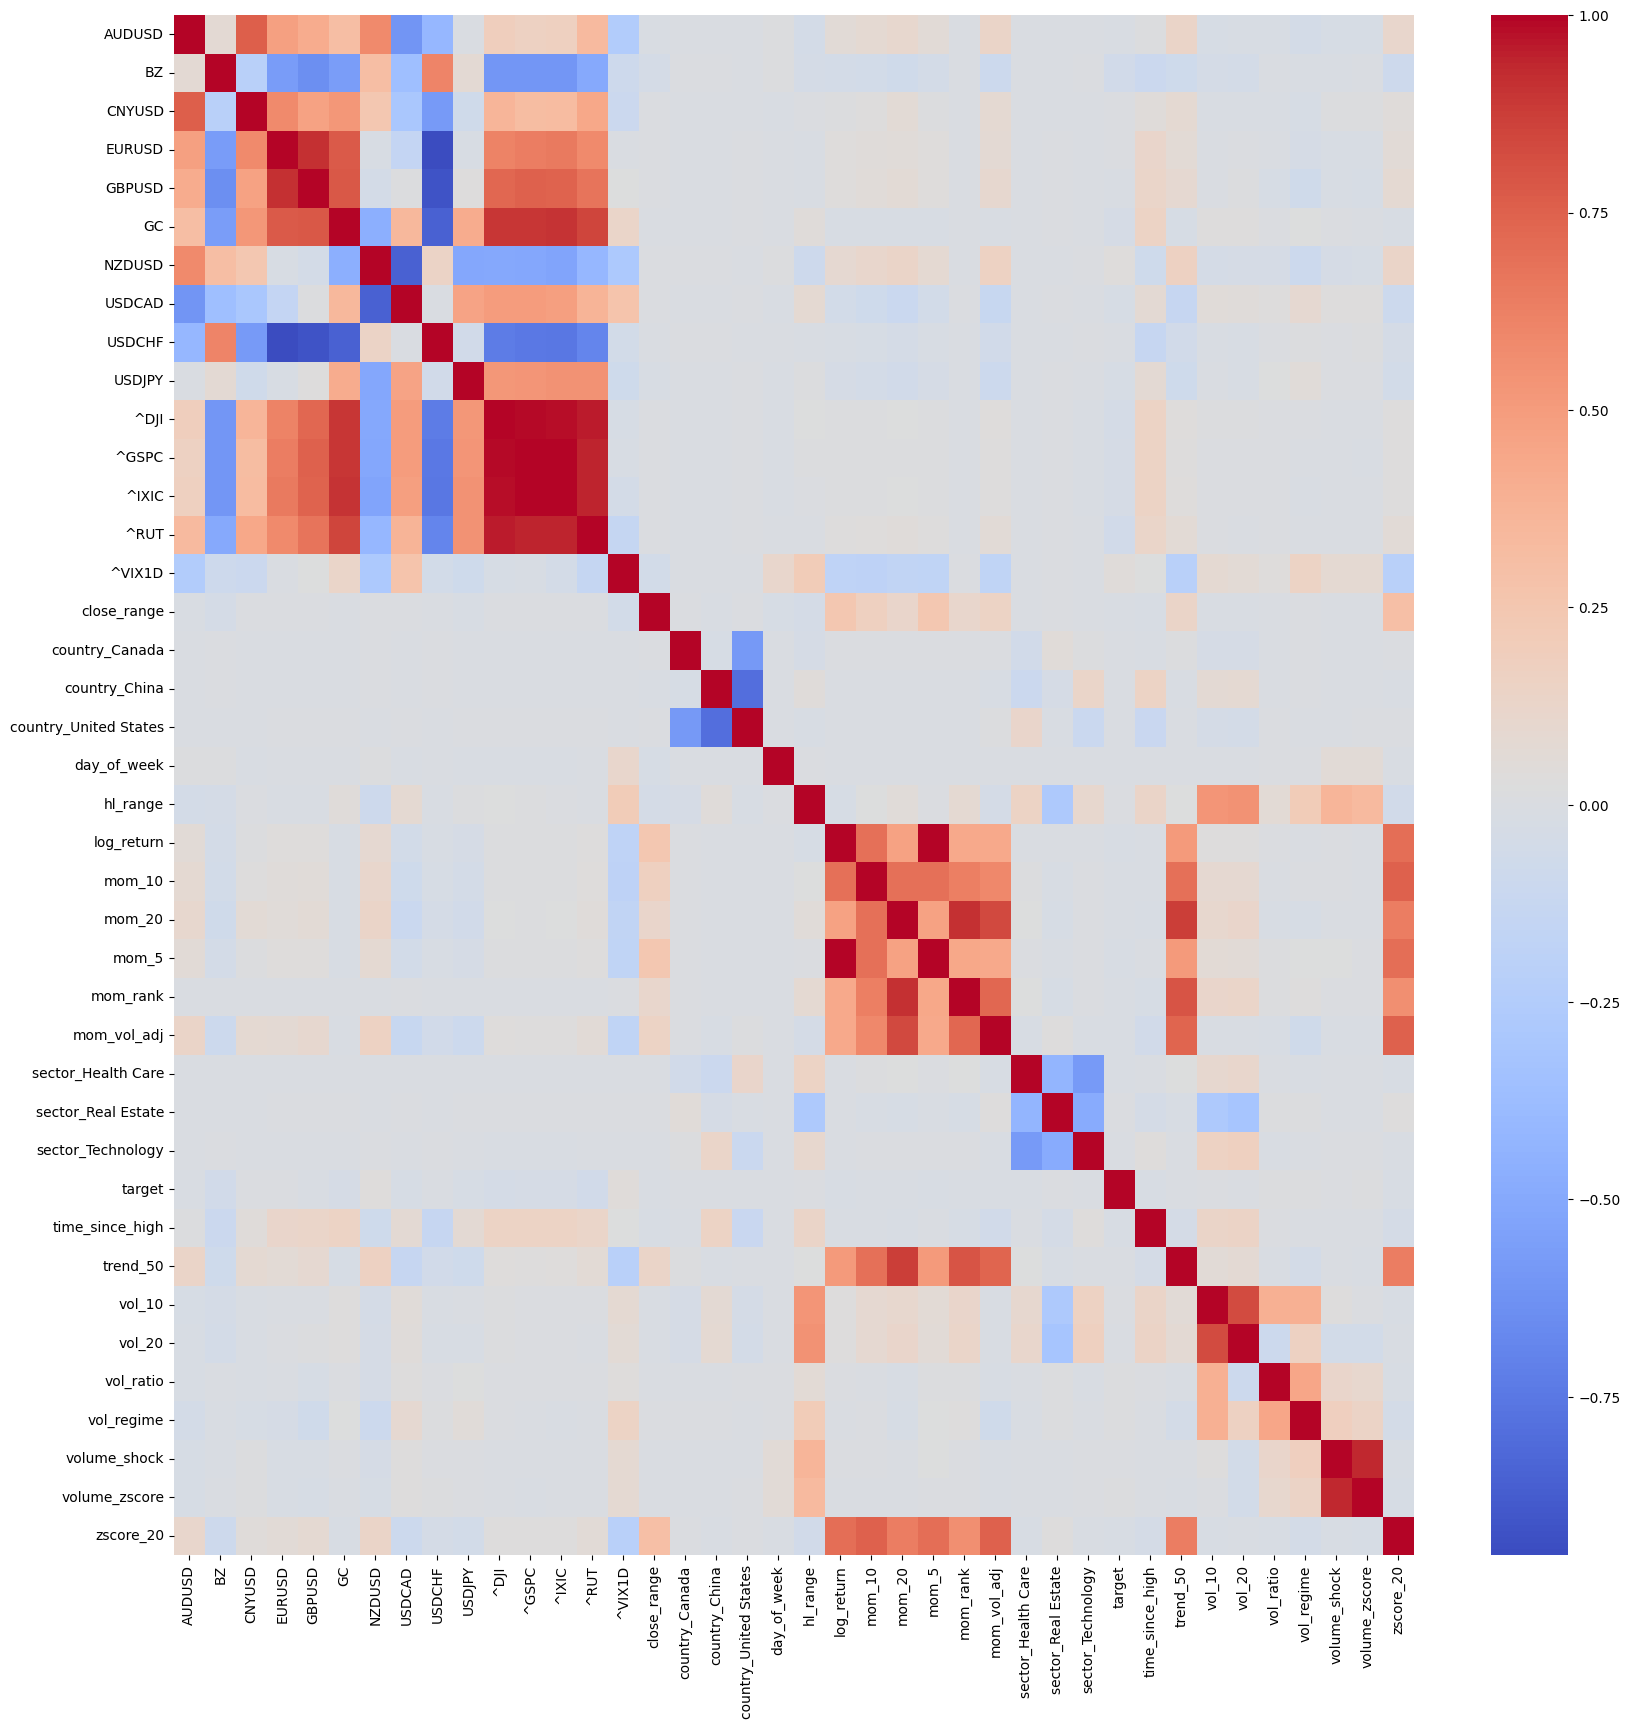

In [39]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [40]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

In [41]:
# check for +inf or -inf in mins and maxs, thrown an exception if found
if maxs.isin([float('inf'), float('-inf')]).any():
    raise ValueError("There are +inf or -inf values in maxs")
if mins.isin([float('inf'), float('-inf')]).any():
    raise ValueError("There are +inf or -inf values in mins")

## Model building

In [42]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [43]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (379524,)
Data Shape: (379524, 39)
Train Data Shape: (303619, 39)
Train Labels Shape: (303619,)
Test Data Shape: (75905, 39)
Test Labels Shape: (75905,)


In [44]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(100, activation='relu',name='layerDense1'))
model.add(Dense(80, activation='relu',name='layerDense2'))
model.add(Dense(20, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 100)            │         4,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 20)             │         1,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,721 (53.60 KB)

 Trainable params: 13,721 (53.60 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/30
1898/1898 - 3s - 2ms/step - loss: 0.0422 - val_loss: 0.0416
Epoch 2/30
1898/1898 - 2s - 1ms/step - loss: 0.0403 - val_loss: 0.0410
Epoch 3/30
1898/1898 - 2s - 1ms/step - loss: 0.0394 - val_loss: 0.0393
Epoch 4/30
1898/1898 - 2s - 1ms/step - loss: 0.0386 - val_loss: 0.0389
Epoch 5/30
1898/1898 - 2s - 1ms/step - loss: 0.0380 - val_loss: 0.0383
Epoch 6/30
1898/1898 - 2s - 1ms/step - loss: 0.0375 - val_loss: 0.0379
Epoch 7/30
1898/1898 - 2s - 1ms/step - loss: 0.0371 - val_loss: 0.0376
Epoch 8/30
1898/1898 - 2s - 1ms/step - loss: 0.0367 - val_loss: 0.0374
Epoch 9/30
1898/1898 - 2s - 1ms/step - loss: 0.0364 - val_loss: 0.0370
Epoch 10/30
1898/1898 - 2s - 1ms/step - loss: 0.0362 - val_loss: 0.0380
Epoch 11/30
1898/1898 - 2s - 1ms/step - loss: 0.0360 - val_loss: 0.0370
Epoch 12/30
1898/1898 - 2s - 1ms/step - loss: 0.0358 - val_loss: 0.0369
Epoch 13/30
1898/1898 - 2s - 1ms/step - loss: 0.0356 - val_loss: 0.0371
Epoch 14/30
1898/1898 - 2s - 1ms/step - loss: 0.0354 - val_loss: 0.0368
E

Model saved to: data\model\model.keras


In [46]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.020757413 0.88145375
Label: -1.4116, Prediction: -0.0979
Label: 2.5849, Prediction: 0.6457
Label: 1.2957, Prediction: 0.1571
Label: -0.0639, Prediction: -0.1148
Label: -1.5550, Prediction: -0.6163
Label: 0.7353, Prediction: 0.0518
Label: -0.7767, Prediction: -0.6457
Label: 0.1870, Prediction: -0.4967
Label: -0.0764, Prediction: -0.3586
Label: 0.1591, Prediction: -1.2368
Label: -1.6705, Prediction: -1.2117
Label: -0.2445, Prediction: -0.7379
Label: -1.0499, Prediction: -0.5531
Label: -0.7597, Prediction: 0.3587
Label: -1.0955, Prediction: 0.5489
Label: -1.5526, Prediction: 0.9271
Label: 3.0000, Prediction: 0.4336
Label: -0.0129, Prediction: -0.0704
Label: 3.0000, Prediction: 1.4807
Label: 1.8941, Prediction: 0.3553
Label: -0.7223, Prediction: 0.1654
Label: -1.7715, Prediction: -0.2557
Label: -0.3185, Prediction: 0.1037
Label: -0.7603, Prediction: 0.0963
Label: 2.3190, Prediction: 0.6135
Label: -1.5696, Prediction: -0.2484
Label: -0.4389, Prediction: -0.0595